# Import Libraries

In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

# Load dataset

In [25]:
df = pd.read_csv("house_price_regression_dataset.csv")
df

,Area_sqft,Bedrooms,Bathrooms,House_Age,Distance_from_City_km,Parking_Spaces,Price_NPR
0,1460,1,2,14,7.6,2,7108000
1,1894,1,1,8,5.0,0,7041000
2,1730,2,2,16,12.0,2,6862000
3,1695,1,3,13,7.5,1,7403000
4,2238,3,2,14,11.2,1,9642000
...,...,...,...,...,...,...,...
195,2586,4,1,23,15.7,2,9932000
196,2134,1,3,4,1.2,2,10322000
197,746,5,3,1,12.4,2,5528000
198,2334,2,1,5,11.7,0,9320000


# See First 5 row

In [26]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,House_Age,Distance_from_City_km,Parking_Spaces,Price_NPR
0,1460,1,2,14,7.6,2,7108000
1,1894,1,1,8,5.0,0,7041000
2,1730,2,2,16,12.0,2,6862000
3,1695,1,3,13,7.5,1,7403000
4,2238,3,2,14,11.2,1,9642000


# See last 5 row

In [27]:
df.tail()

,Area_sqft,Bedrooms,Bathrooms,House_Age,Distance_from_City_km,Parking_Spaces,Price_NPR
195,2586,4,1,23,15.7,2,9932000
196,2134,1,3,4,1.2,2,10322000
197,746,5,3,1,12.4,2,5528000
198,2334,2,1,5,11.7,0,9320000
199,2443,2,2,20,14.6,0,9231000


# No. of rows and columns

In [28]:
df.shape

(200, 7)

In [29]:
df.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'House_Age',
       'Distance_from_City_km', 'Parking_Spaces', 'Price_NPR'],
      dtype='object')

# Statistical Summary

In [30]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,House_Age,Distance_from_City_km,Parking_Spaces,Price_NPR
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,1862.825000,2.940000,1.890000,15.040000,10.709000,1.050000,8.026595e+06
std,657.977428,1.454986,0.843479,9.254004,5.163646,0.831237,2.201731e+06
min,601.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.398000e+06
25%,1337.500000,2.000000,1.000000,7.000000,7.300000,0.000000,6.321750e+06
50%,1895.500000,3.000000,2.000000,16.000000,11.200000,1.000000,8.031000e+06
75%,2374.500000,4.000000,3.000000,23.000000,14.750000,2.000000,9.790750e+06
max,2991.000000,5.000000,3.000000,30.000000,20.000000,2.000000,1.313300e+07


# Check missing values

In [31]:
df.isnull().sum()

Area_sqft                0
Bedrooms                 0
Bathrooms                0
House_Age                0
Distance_from_City_km    0
Parking_Spaces           0
Price_NPR                0
dtype: int64

# Simple linear regression

In [32]:
X=df[["Area_sqft"]]
y=df["Price_NPR"]

# Visualize The relationship

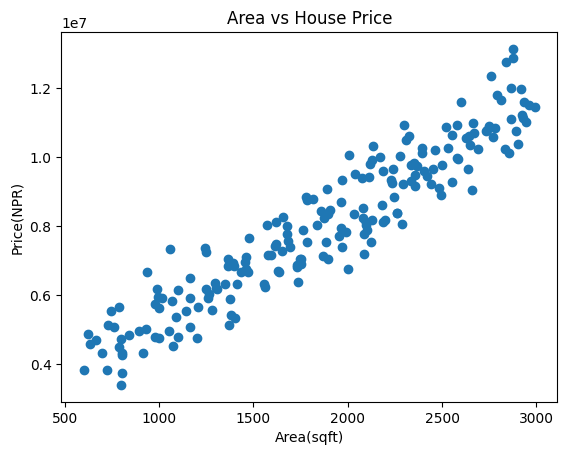

In [33]:
plt.scatter(X,y)
plt.xlabel("Area(sqft)")
plt.ylabel("Price(NPR)")

plt.title("Area vs House Price")
plt.show()

# Train test split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create a model

In [37]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Train the model

In [38]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# See what model learnt

In [39]:
print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_[0])

Intercept: 2020198.1581207681
Coefficient: 3210.326489753477


In [ ]:

print(
    f"Price={model.intercept_:.2f}+"
    f"{model.coef_[0]:.2f} x Area"
)

Price=2020198.16+3210.33 x Area


# predict all test data

In [42]:
y_pred = model.predict(X_test)

# Compare actual and predicted

In [ ]:

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
95,10217000,9.927232e+06
15,9426000,8.810039e+06
30,5086000,5.750598e+06
158,9811000,8.826090e+06
128,6845000,6.498604e+06
115,6496000,5.753808e+06
69,7780000,7.400705e+06
170,8386000,9.278746e+06
174,9227000,9.387897e+06
45,7822000,8.408748e+06


# Calculate MAE

In [44]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 574343.1114785086


# Calculate MSE

In [45]:
from sklearn.metrics import mean_squared_error
mse= mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 515513498545.38855


# Calculate RMSE

In [46]:
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 717992.6869720808


# Calculate R²

In [47]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R²:",r2)

R²: 0.8493037970547501


# Regression line

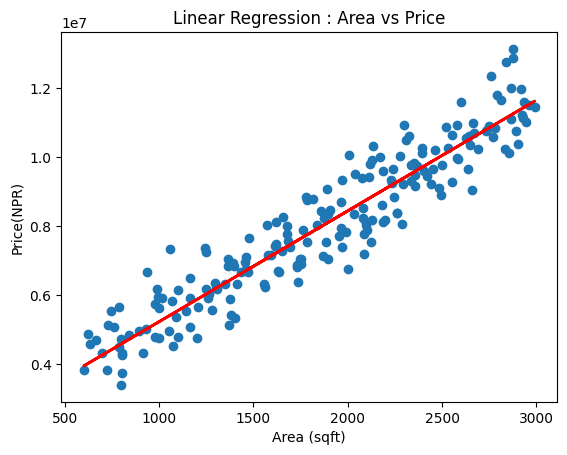

In [48]:
plt.scatter(X,y)
plt.plot(X,model.predict(X),color="red",linewidth=2)

plt.xlabel("Area (sqft)")
plt.ylabel("Price(NPR)")
plt.title("Linear Regression : Area vs Price")

plt.show()

# Multi Regression

In [49]:
X= df[
    [
        "Area_sqft",
        "Bedrooms",
        "Bathrooms",
        "House_Age",
        "Distance_from_City_km",
        "Parking_Spaces"
    ]
]

y= df ["Price_NPR"]

# Split Again

In [50]:
X_train,X_test,y_train,y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create multi regression again

In [51]:
model= LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# See all Coefficient

In [52]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficients": model.coef_
})
coefficients

,Feature,Coefficients
0,Area_sqft,3237.675562
1,Bedrooms,247942.978653
2,Bathrooms,290830.279018
3,House_Age,-38846.963715
4,Distance_from_City_km,-54982.536315
5,Parking_Spaces,201242.466476


# Intercept

In [53]:
print("Intercept:", model.intercept_)

Intercept: 1677615.0648813834


# Predict a new House

In [54]:
#Area = 2000 sqft
#Bedrooms=3
#Bathrooms=2
#Age=5 years
#Distance=7 km
#Parking=2

In [55]:
new_house=[[2000,3,2,5,7,2]]
prediction = model.predict(new_house)
print("Predicted Price:", prediction[0])

Predicted Price: 9301828.0440309


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Evaluate

In [56]:
y_pred = model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2= r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R²:",r2)

MAE: 280622.1248046246
MSE: 106335136354.29935
RMSE: 326090.68731611967
R²: 0.9689158453978922
